# 06 - Final Results

We aggregate the results saved by previous notebooks and produce summary tables and plots.

c:\Users\ASUS\OneDrive\Desktop\fair_ml\src\viz.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")
c:\Users\ASUS\OneDrive\Desktop\fair_ml\src\viz.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


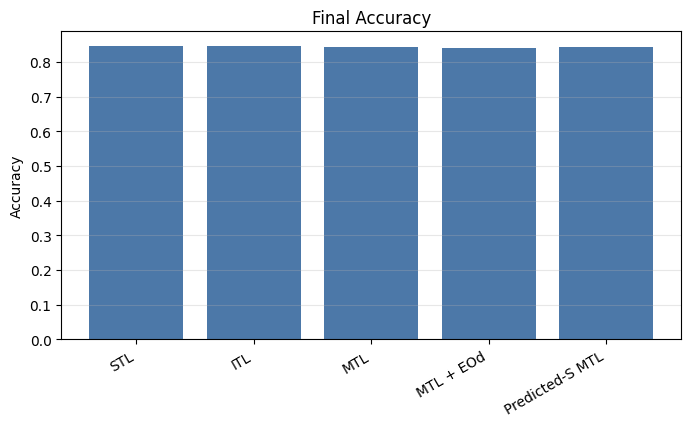

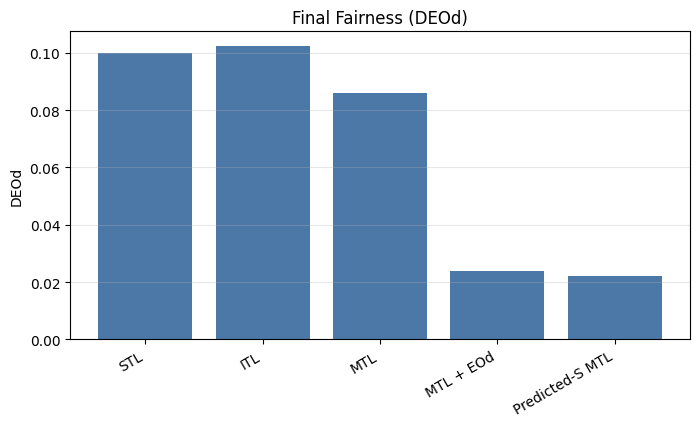

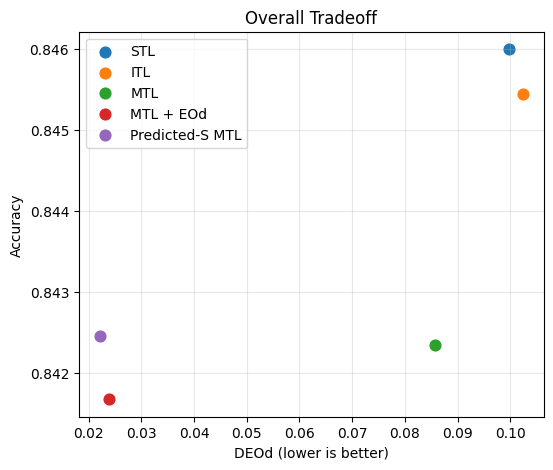

In [12]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from src.results_utils import load_results
from src.viz import bar_compare, scatter_fairness_accuracy

clear_output(wait=True)
plt.close("all")

results = load_results()
results.keys()

rows = []
if "baselines" in results:
    rows.append({"model": "STL", **results["baselines"]["STL"]})
    rows.append({"model": "ITL", **results["baselines"]["ITL"]})
if "mtl" in results:
    rows.append({"model": "MTL", "accuracy": results["mtl"]["accuracy"], "deod": results["mtl"]["deod"]})
if "fairness" in results:
    rows.append({"model": "MTL + EOd", **results["fairness"]["mtl_fair"]})
if "pred_sensitive" in results:
    rows.append({"model": "Predicted-S MTL", **results["pred_sensitive"]["mtl_pred"]})
summary = pd.DataFrame(rows)
summary

bar_compare(summary["model"], summary["accuracy"], "Final Accuracy", "Accuracy")
bar_compare(summary["model"], summary["deod"], "Final Fairness (DEOd)", "DEOd")

scatter_fairness_accuracy(summary["accuracy"], summary["deod"], summary["model"], "Overall Tradeoff");

## Discussion
- MTL typically improves both accuracy and group robustness over STL/ITL.
- Fairness constraints lower DEOd but may reduce accuracy slightly.
- Predicted sensitive attributes can provide a practical compromise in deployment.